## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 2 - Notebook 1 - K-Nearest Neighbors
---

## Importing the Required Libraries
---

In [1]:
import numpy as np

from scipy import spatial, stats
from sklearn import datasets, model_selection, preprocessing, neighbors, metrics, svm, naive_bayes

import matplotlib.pylab as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pandas as pd
import seaborn as sns

%matplotlib inline

## Preparing the Iris Dataset
---

* We will use a very well-known dataset, the **Iris dataset**.

* 3 classes:
    * Iris Setosa;
    * Iris Versicolor;
    * Iris Virginica.

* 150 samples:
    * 50 samples from each class.

* 4 features:
    * Sepal length;
    * Sepal width;
    * Petal length;
    * Petal width.

*https://en.wikipedia.org/wiki/Iris_flower_data_set*

* References:
    * https://en.wikipedia.org/wiki/Iris_flower_data_set
    * R. A. Fisher (1936). "The use of multiple measurements in taxonomic problems." *Annals of Eugenics*, 7(2): 179–188.
    * http://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

In [2]:
# Load the Iris dataset
iris = datasets.load_iris()

# Data
X = iris.data

# Labels
y = iris.target

In [3]:
# Number of samples
num_objs = X.shape[0]
# Number of features
num_feat = X.shape[1]
# Number of classes
num_classes = len(np.unique(y))
# Feature names
feat_names = iris.feature_names
# Class names
class_names = list(iris.target_names)

In [4]:
print(f'Number of samples: {num_objs}')
print(f'Number of features: {num_feat}')
print(f'Features: {str(feat_names)[1:-1]}')
print(f'Number of classes: {num_classes}')
print(f'Classes: {str(class_names)[1:-1]}')

Number of samples: 150
Number of features: 4
Features: 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'
Number of classes: 3
Classes: np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')


### Visualizing the Iris Dataset

In [5]:
df = pd.DataFrame(X, columns=feat_names)
df['class'] = y

pd.set_option('display.expand_frame_repr', False)
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


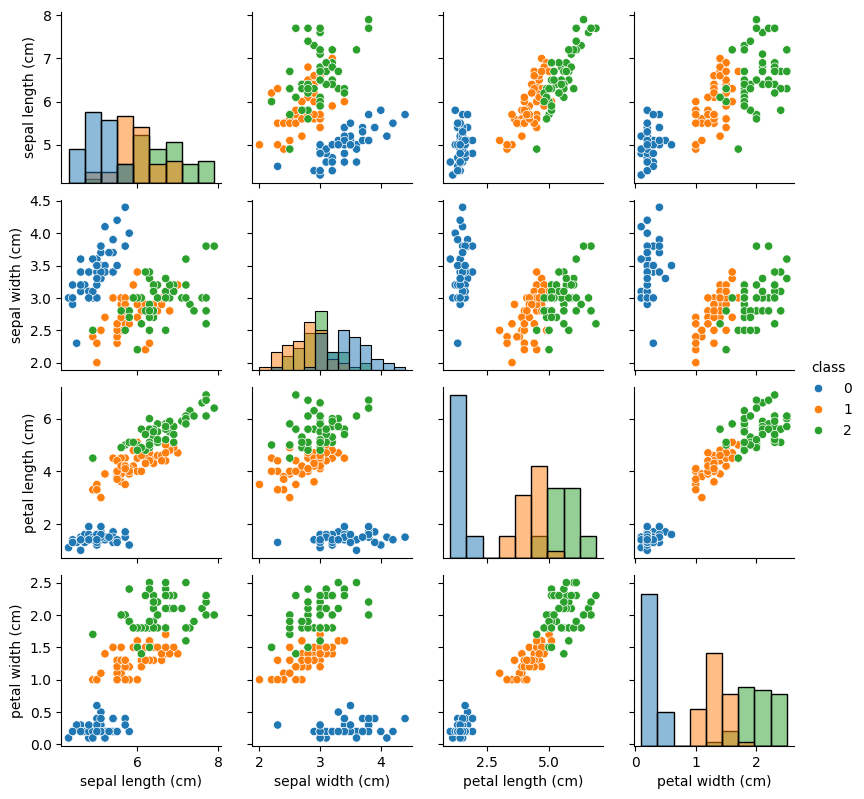

In [6]:
g = sns.PairGrid(df, hue='class', vars=feat_names, palette='tab10')
g.fig.set_size_inches(8, 8)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()

### Preparing the Dataset

In [7]:
# Keep all three classes from the Iris dataset:
# Setosa (0), Versicolor (1), and Virginica (2)
X = iris.data
y = iris.target

# Select only two features:
# Sepal length (0) and sepal width (1)
X_ = X[:, [0, 1]]

In [8]:
# Split the dataset into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_,
    y,
    test_size=0.3,
    random_state=42
)

### Normalizing the Features

In [9]:
# Create the standardization object
scaler = preprocessing.StandardScaler()

# Compute the mean and standard deviation using only the training set
scaler.fit(X_train)

# Standardize the training set
X_train_norm = scaler.transform(X_train)

# Standardize the test set using the training set statistics
X_test_norm = scaler.transform(X_test)

## K-Nearest Neighbors
----

### Nearest Neighbor:
* One of the simplest approaches to classification.
* A supervised, non-parametric method.
* Given a dataset $X$ containing $N$ samples already classified into $M$ classes $C_i$, we want to classify a new sample $x$.
* We identify the sample in $X$ that is closest (most similar) to $x$ and assign $x$ to the same class.
* Similarity is measured using a distance metric in the feature space.
    * Usually, the Euclidean distance.


### K-Nearest Neighbors (k-NN):
* An extension of the nearest neighbor method.
* The $k$ nearest neighbors of the new sample are identified, where $k$ is a positive integer.
* The new sample is assigned to the most frequent class among its $k$ nearest neighbors.
* In case of a tie, a tie-breaking rule must be used.

In [10]:
class SimpleKNN:
    """Simple implementation of a k-NN classifier.

    Reference
    ---------
    [1] COSTA & CESAR-JR. Shape analysis and classification: theory and practice. CRC Press, 2000.
        Section 8.2: Supervised Pattern Classification.
    """

    def __init__(self, k=1):
        """Constructor."""
        self.k = k
        # Initilize the distances matrix to None. It will be computed during testing.
        self.dist_mat = None

    def fit(self, X_train, y_train):
        """Store the training samples and labels."""

        print('\nTraining the model...')

        if self.k < 1:
            raise ValueError("k must be greater than or equal to 1.")

        if self.k > X_train.shape[0]:
            raise ValueError("k cannot be greater than the number of training samples.")

        # k-NN is a lazy learning method:
        # no model is explicitly learned during training.
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test, verbose=False):
        """Classify a set of unseen samples."""

        print('\nTesting the model...')

        # Compute the distances between test and training samples
        # Rows: test samples. Columns: training samples
        self.dist_mat = spatial.distance.cdist(
            X_test,
            self.X_train,
            metric='euclidean'
        )

        if verbose:
            print('\nDistance matrix:')
            print(self.dist_mat.shape)

            with np.printoptions(precision=4, suppress=True):
                print(self.dist_mat)

        # Find the indices of the k nearest training samples
        neighbor_indices = self.dist_mat.argsort(axis=1)[:, :self.k]

        if verbose:
            print('\nIndices of the nearest neighbors:')
            print(neighbor_indices.shape)
            print(neighbor_indices)

        # Get the class labels of the nearest neighbors
        neighbor_labels = self.y_train[neighbor_indices]

        if verbose:
            print('\nClasses of the nearest neighbors:')
            print(neighbor_labels.shape)
            print(neighbor_labels)

        # Majority voting
        y_pred = np.array([
            np.bincount(labels).argmax() for labels in neighbor_labels
        ])

        if verbose:
            print('\nPredicted classes:')
            print(y_pred.shape)
            print(y_pred)

        return y_pred

## Training the k-NN
---

### Training the k-NN with $k=1$ (NN)

In [11]:
# Create an instance of the SimpleKNN classifier with k=1
knn = SimpleKNN(k=1)

# Train the k-NN classifier using the training set.
# k-NN is a lazy learning method. The training samples and labels are only stored for using during testing.
knn.fit(X_train_norm, y_train)


Training the model...


In [12]:
# Test the k-NN classifier using the test set
pred_knn = knn.predict(X_test_norm)


Testing the model...


#### Plotting the k-NN distance matrix

In [13]:
# Shape of the distance matrix
print(knn.dist_mat.shape)
# Print the distance matrix
print(knn.dist_mat)

(45, 105)
[[1.20164277 0.24115957 0.80538815 ... 2.90096031 0.60082139 1.29772084]
 [3.36668621 2.5053335  1.87923901 ... 0.49464175 2.88084273 2.55574541]
 [2.69578213 1.7549558  1.97369994 ... 4.06511646 2.29101588 1.20164277]
 ...
 [2.2164815  0.86627158 0.36173935 ... 2.41616444 1.61741054 0.53866919]
 [3.59991767 2.85292138 2.26628421 ... 0.53866919 3.15526001 2.97692178]
 [3.12050853 2.41616444 1.87753222 ... 0.86627158 2.68218082 2.64971988]]


#### Visualizing the k-NN distance matrix

In [14]:
def plot_distance_matrix(knn, k=1, figsize=(10, 6)):
    """Plot the distance matrix and highlight the k nearest neighbors."""

    fig, ax = plt.subplots(figsize=figsize)

    # Distance matrix
    im = ax.imshow(
        knn.dist_mat,
        aspect='auto',
        cmap='viridis'
    )

    # Indices of the k nearest neighbors of each test sample
    nearest = knn.dist_mat.argsort(axis=1)[:, :k]

    # Test sample indices
    test_indices = np.arange(knn.dist_mat.shape[0])

    # Highlight the k nearest neighbors
    for i in range(k):
        ax.scatter(
            nearest[:, i],
            test_indices,
            marker='o',
            s=35,
            facecolors='red',
            edgecolors='white',
            linewidths=0.7,
            label='Nearest neighbors' if i == 0 else None
        )

    ax.set_xlabel('Training samples')
    ax.set_ylabel('Test samples')
    ax.set_title(f'Distance Matrix ($k={k}$)')

    fig.colorbar(
        im,
        ax=ax,
        label='Euclidean distance'
    )

    ax.legend()

    plt.show()

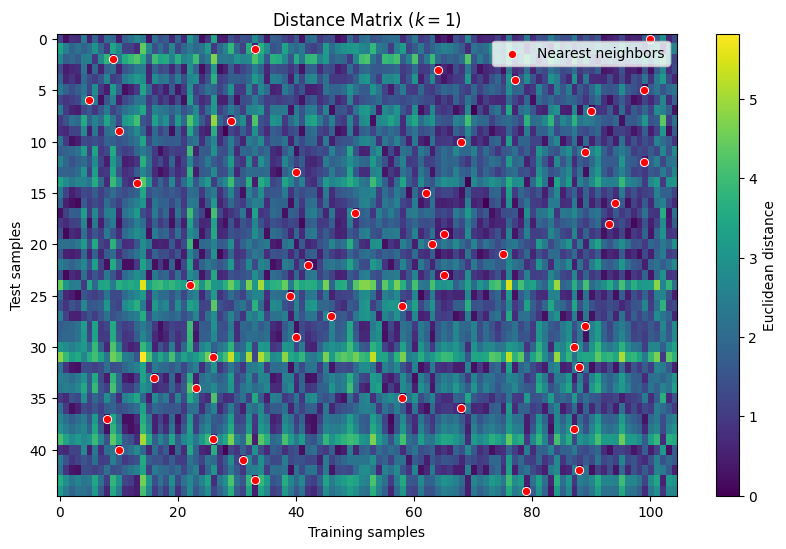

In [15]:
plot_distance_matrix(knn, k=1)

#### Model Evaluation


Confusion matrix:
[[19  0  0]
 [ 0  8  5]
 [ 0  8  5]]

Confusion matrix visualization:


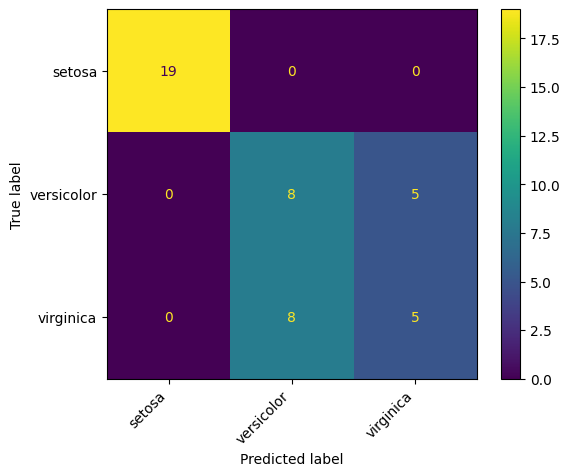

In [16]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, pred_knn))

# Confusion matrix visualization
print('\nConfusion matrix visualization:')

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_knn,
    display_labels=class_names
)

plt.xticks(rotation=45, ha='right')
plt.show()

In [17]:
print('\nClassification report:')
print(
    metrics.classification_report(
        y_test,
        pred_knn,
        target_names=class_names
    )
)

accuracy = metrics.accuracy_score(y_test, pred_knn)
print(f'Accuracy: {accuracy:.4f}')


Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.50      0.62      0.55        13
   virginica       0.50      0.38      0.43        13

    accuracy                           0.71        45
   macro avg       0.67      0.67      0.66        45
weighted avg       0.71      0.71      0.71        45

Accuracy: 0.7111


### Training the k-NN with $k=3$ 

In [18]:
# Create an instance of the SimpleKNN classifier with k=1
knn = SimpleKNN(k=3)

# Train the k-NN classifier using the training set.
# k-NN is a lazy learning method. The training samples and labels are only stored for using during testing.
knn.fit(X_train_norm, y_train)


Training the model...


In [19]:
# Test the k-NN classifier using the test set
pred_knn = knn.predict(X_test_norm)


Testing the model...


#### Plotting the k-NN distance matrix

In [20]:
# Shape of the distance matrix
print(knn.dist_mat.shape)
# Print the distance matrix
print(knn.dist_mat)

(45, 105)
[[1.20164277 0.24115957 0.80538815 ... 2.90096031 0.60082139 1.29772084]
 [3.36668621 2.5053335  1.87923901 ... 0.49464175 2.88084273 2.55574541]
 [2.69578213 1.7549558  1.97369994 ... 4.06511646 2.29101588 1.20164277]
 ...
 [2.2164815  0.86627158 0.36173935 ... 2.41616444 1.61741054 0.53866919]
 [3.59991767 2.85292138 2.26628421 ... 0.53866919 3.15526001 2.97692178]
 [3.12050853 2.41616444 1.87753222 ... 0.86627158 2.68218082 2.64971988]]


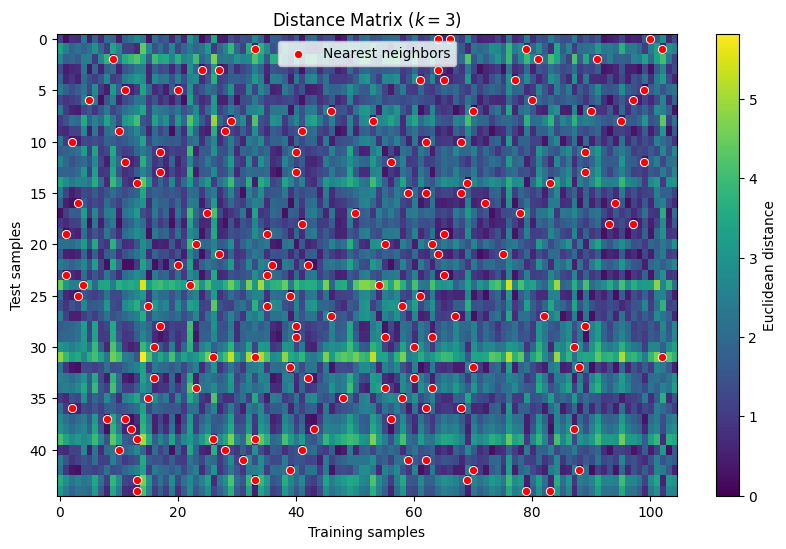

In [21]:
plot_distance_matrix(knn, k=3)

#### Model Evaluation


Confusion matrix:
[[19  0  0]
 [ 0  6  7]
 [ 0  2 11]]

Confusion matrix visualization:


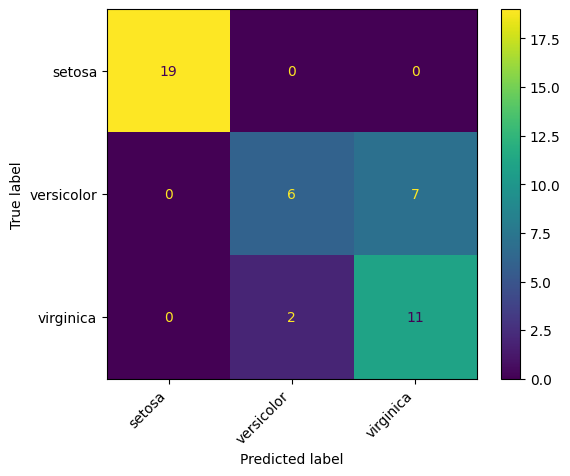

In [22]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, pred_knn))

# Confusion matrix visualization
print('\nConfusion matrix visualization:')

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_knn,
    display_labels=class_names
)

plt.xticks(rotation=45, ha='right')
plt.show()

In [23]:
print('\nClassification report:')
print(
    metrics.classification_report(
        y_test,
        pred_knn,
        target_names=class_names
    )
)

accuracy = metrics.accuracy_score(y_test, pred_knn)
print(f'Accuracy: {accuracy:.4f}')


Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.75      0.46      0.57        13
   virginica       0.61      0.85      0.71        13

    accuracy                           0.80        45
   macro avg       0.79      0.77      0.76        45
weighted avg       0.82      0.80      0.79        45

Accuracy: 0.8000


### Implementando com scikit-learn

In [24]:
clf = neighbors.KNeighborsClassifier(n_neighbors=3)

clf.fit(X_train_norm, y_train)

pred = clf.predict(X_test_norm)

#### Model Evaluation


Confusion matrix:
[[19  0  0]
 [ 0  8  5]
 [ 0  2 11]]

Confusion matrix visualization:


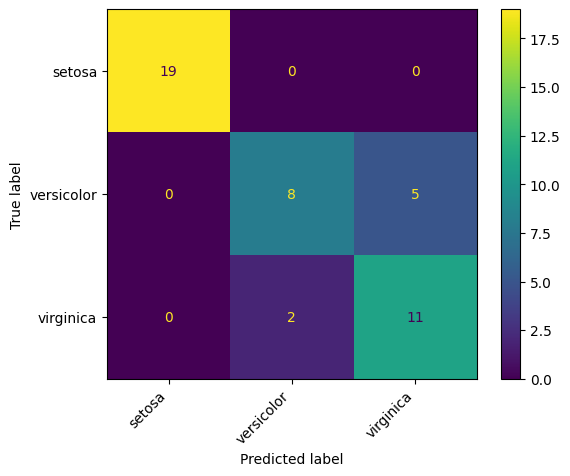

In [25]:
print('\nConfusion matrix:')
print(metrics.confusion_matrix(y_test, pred))

# Confusion matrix visualization
print('\nConfusion matrix visualization:')

metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=class_names
)

plt.xticks(rotation=45, ha='right')
plt.show()

In [26]:
print('\nClassification report:')
print(
    metrics.classification_report(
        y_test,
        pred,
        target_names=class_names
    )
)

accuracy = metrics.accuracy_score(y_test, pred)
print(f'Accuracy: {accuracy:.4f}')


Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.80      0.62      0.70        13
   virginica       0.69      0.85      0.76        13

    accuracy                           0.84        45
   macro avg       0.83      0.82      0.82        45
weighted avg       0.85      0.84      0.84        45

Accuracy: 0.8444


## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---

* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* scikit-learn - User Guide.
    * https://scikit-learn.org/stable/user_guide.html